# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:



<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>



**¡Empecemos!** &#x1F680;


# Proyecto Sprint 10- TIENDA ONLINE

- Objetivo: Recopilar una lista de hipótesis para ayudar en aumentar los ingresos.

* priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

In [1]:
#Cargamos las librerias y los datasets
import pandas as pd
import scipy.stats as stats
import datetime as dt
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns



hypo = pd.read_csv('https://raw.githubusercontent.com/LuisPeza/Proyecto_10/refs/heads/main/hypotheses_us.csv', sep=';')
orders = pd.read_csv('https://raw.githubusercontent.com/LuisPeza/Proyecto_10/refs/heads/main/orders_us.csv', sep=',') 
visitors = pd.read_csv('https://raw.githubusercontent.com/LuisPeza/Proyecto_10/refs/heads/main/visitors_us.csv', sep=',')

In [2]:
#Revisamos la informacion de datasets
hypo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [4]:
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


## Preprocesamiento de datos

- Vamos a cambiar los tipos de datos erroneos de las columnas date


In [5]:
#Vamos a cambiar el tipo de dato de la columna date a datetime de la tabla orders
orders['date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')

In [6]:
#Vamos a cambiar el tipo de dato de la columna date en la tablar visitors a datetime
visitors['date'] = pd.to_datetime(visitors['date'], format='%Y-%m-%d')

In [7]:
#Vamos a realizar un groupby para encontrar los usuarios unicos que estan en cada grupo


## Paso 1. Priorizar hipótesis

### 1. Aplicar el framework ICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.

In [8]:
#Obtenemos el ICE con la formula ICE = (Impacto * Confianza) / Esfuerzo
hypo['ICE'] = (hypo['Impact']*hypo['Confidence'])/hypo['Effort']
print(hypo[['Hypothesis','ICE']].sort_values(by='ICE', ascending=False))

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


### 2. Aplicar el framework RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.

In [9]:
# Obtnemos el RICE con la formula RICE = (Reach * Impact * Confidence) / Effort
hypo['RICE'] = (hypo['Reach']*hypo['Impact']*hypo['Confidence'])/hypo['Effort']
print(hypo[['Hypothesis','RICE']].sort_values(by='RICE', ascending=False))


                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


- En ICE la hipotesis 8 tuvo el mayor valor  y en RICE la posicion con mayor valor fue la hipotesis 7 en ICE la hipotesis 7 quedo en 3 lugar y en RICE la hipotesis 8 quedo en la posicion 5

- La hipótesis 8 probablemente tiene buen impacto, confianza y facilidad, pero bajo alcance
La hipótesis 7 tiene un alto alcance que compensa otros factores más bajos

In [10]:
# Después de calcular ICE y RICE
comparison = pd.DataFrame({
    'Hypothesis': hypo['Hypothesis'],
    'ICE_Score': hypo['ICE'],
    'ICE_Rank': hypo['ICE'].rank(ascending=False),
    'RICE_Score': hypo['RICE'], 
    'RICE_Rank': hypo['RICE'].rank(ascending=False),
    'Rank_Change': hypo['ICE'].rank(ascending=False) - hypo['RICE'].rank(ascending=False)
})

# Ordenar por RICE para mostrar nueva priorización
comparison_sorted = comparison.sort_values('ICE_Score', ascending=False)

In [11]:
print(comparison_sorted)

                                          Hypothesis  ICE_Score  ICE_Rank  \
8  Launch a promotion that gives users discounts ...  16.200000       1.0   
0  Add two new channels for attracting traffic. T...  13.333333       2.0   
7  Add a subscription form to all the main pages....  11.200000       3.0   
6  Show banners with current offers and sales on ...   8.000000       4.0   
2  Add product recommendation blocks to the store...   7.000000       5.0   
1  Launch your own delivery service. This will sh...   2.000000       6.0   
5  Add a customer review page. This will increase...   1.333333       7.0   
3  Change the category structure. This will incre...   1.125000       8.0   
4  Change the background color on the main page. ...   1.000000       9.0   

   RICE_Score  RICE_Rank  Rank_Change  
8        16.2        5.0         -4.0  
0        40.0        3.5         -1.5  
7       112.0        1.0          2.0  
6        40.0        3.5          0.5  
2        56.0        2.0     

- Tenemos que la hipotesis 8 tiene un rango de cambio de -4
- La hipotesis 7 que en rango de RICE quedo en 1ero tiene un rango de cambio de 2 

In [12]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB



<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Has implementado correctamente las fórmulas de ICE y RICE para priorizar hipótesis, utilizando los factores relevantes de impacto, confianza, esfuerzo y alcance. La visualización de rankings está clara, y el análisis de los cambios entre los frameworks está bien justificado. Excelente trabajo destacando cómo el alcance (Reach) influye en el cambio de posición entre hipótesis al pasar de ICE a RICE. Esto demuestra comprensión del propósito de ambos modelos.
</div>


## Parte 2. Análisis del test A/B

In [13]:
#Vamos a realizar una slice para obtener solo los usuarios que esten solo en 1 grupo y no en ambos
#Contamos los visitorId unicos por grupo 
orders_new= orders.groupby('visitorId').agg({'group': 'nunique'}).reset_index()
#Nos quedamos con los que estan en un solo grupo
orders_new = orders_new[orders_new['group'] == 1]
#Hacemos un merge para quedarnos con los datos de orders que solo estan en un grupo
orders_new = orders_new.merge(orders, on='visitorId', how='left')


### 1. Representa gráficamente el ingreso acumulado por grupo. Haz conclusiones y conjeturas.

In [14]:
#Vamos a obtener el dia de la fecha d
orders_new['day'] = orders_new['date'].dt.day


In [15]:
#Hacemos un groupby con group y day y sumamos los valores de revenue
ingresos_grupo = orders_new.groupby(['day','group_y'])['revenue'].sum().reset_index()

#Obtenemos el ingreso acumulado
ingresos_grupo['acumulado'] = ingresos_grupo.groupby('group_y')['revenue'].cumsum() 

#Comprobamos los datos
print(ingresos_grupo['acumulado'])

0      2266.6
1       967.2
2      3734.9
3      3535.3
4      5550.1
       ...   
57    74576.7
58    52363.7
59    77863.5
60    53212.0
61    79651.2
Name: acumulado, Length: 62, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

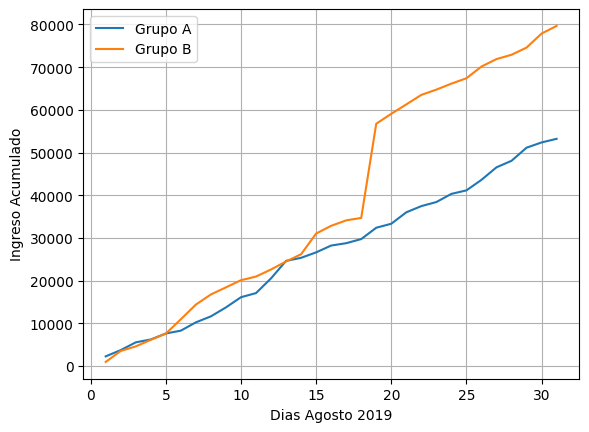

In [16]:
# Separar grupos
group_a = ingresos_grupo[ingresos_grupo['group_y'] == 'A']
group_b = ingresos_grupo[ingresos_grupo['group_y'] == 'B']

# Graficamos
#Asignamos los valores de x para el dia y los de y para el ingreso acumulado del Grupo A
plt.plot(group_a['day'], group_a['acumulado'], label='Grupo A')
#Asignamos los valores de x para el dia y los de y para el ingreso acumulado del Grupo B
plt.plot(group_b['day'], group_b['acumulado'], label='Grupo B')
plt.xlabel('Dias Agosto 2019')
plt.ylabel('Ingreso Acumulado')
plt.grid(True)
plt.legend()

plt.show

- Vemos que los ingresos acumulados del grupo B son significativamente mayores que el grupo A y los valores crecen exponencialmente a partir del dia 19 de agosto

 ### 2. Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.

In [17]:
# Agrupar por fecha y grupo, calcular promedio diario
promedio_acu = orders_new.groupby(['day', 'group_y'])['revenue'].mean().reset_index()
promedio_acu.rename(columns={'revenue': 'avg_order_size'}, inplace=True)


In [18]:
#calculamos el promedio acumulado
# Para cada grupo, calcular el promedio acumulado
promedio_acu['cumulative_avg'] = promedio_acu.groupby('group_y')['avg_order_size'].expanding().mean().values

In [19]:
print(promedio_acu)

    day group_y  avg_order_size  cumulative_avg
0     1       A       98.547826       98.547826
1     1       B       56.894118       87.913387
2     2       A       77.278947       83.820036
3     2       B      111.656522       78.217299
4     3       A       75.633333       75.282930
..  ...     ...             ...             ...
57   29       B      112.080000      143.326716
58   30       A      136.544444      139.848327
59   30       B      156.514286      138.890798
60   31       A      106.037500      139.478248
61   31       B      105.158824      138.371170

[62 rows x 4 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

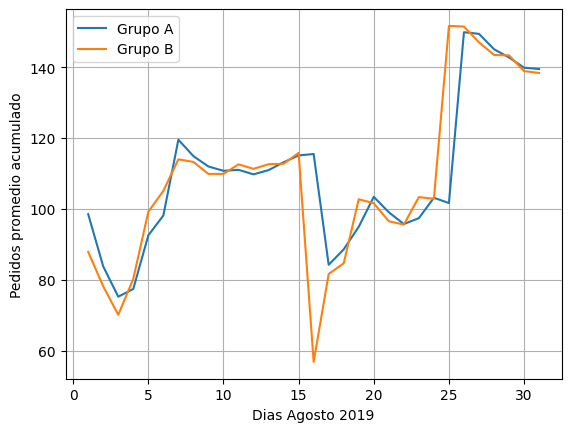

In [20]:
# Separar grupos

group_a_avg = promedio_acu[promedio_acu['group_y'] == 'A']
group_b_avg = promedio_acu[promedio_acu['group_y'] == 'B']


# Graficamos
#Asignamos los valores de x para el dia y los de y para el ingreso acumulado del Grupo A
plt.plot(group_a_avg['day'], group_a_avg['cumulative_avg'], label='Grupo A')
#Asignamos los valores de x para el dia y los de y para el ingreso acumulado del Grupo B
plt.plot(group_b_avg['day'], group_b_avg['cumulative_avg'], label='Grupo B')
plt.xlabel('Dias Agosto 2019')
plt.ylabel('Pedidos promedio acumulado')
plt.grid(True)
plt.legend()

plt.show

- Notamos qu el grupo A se mantiene un poco mas estable en cuanto al promedio de pedidos, tenemos un pico alto de pedidos en el dia 25 para el grupo B y el dia 25 para el grupo A
- Pero ambos grupos se mantienen muy parecido en el numero de pedidos promedio. 

### 3. Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. Haz conclusiones y conjeturas.

In [21]:
# Para obtener la diferencia relativa usamos esta formula
#Diferencia Relativa = ((Valor_B - Valor_A) / Valor_A) × 100

group_a_avg = promedio_acu[promedio_acu['group_y'] == 'A']
group_b_avg = promedio_acu[promedio_acu['group_y'] == 'B']

# Unir ambos datasets por fecha
comparison = pd.merge(group_a_avg, group_b_avg, on='day', suffixes=('_A', '_B'))

# Calcular diferencia relativa (en porcentaje)
comparison['relative_diff'] = ((comparison['cumulative_avg_B'] - comparison['cumulative_avg_A']) / comparison['cumulative_avg_A']) * 100

'plt.show()'

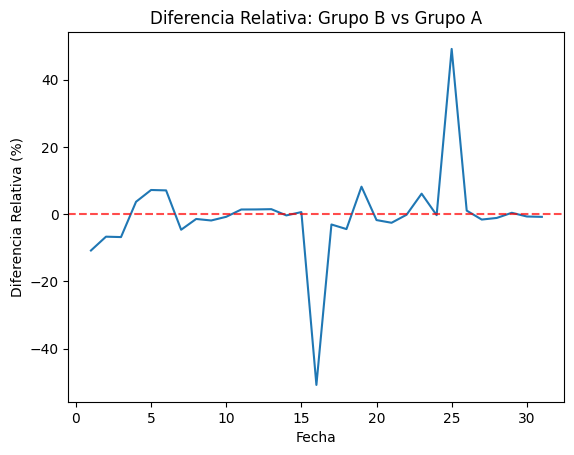

In [22]:
#Graficar

plt.plot(comparison['day'], comparison['relative_diff'])
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)  # Línea de referencia en 0%
plt.xlabel('Fecha')
plt.ylabel('Diferencia Relativa (%)')
plt.title('Diferencia Relativa: Grupo B vs Grupo A')
'plt.show()'


- Existe un pico en el grupo B con arriba de +40 para el dia 25 tiene mas pedidos ese dia que el grupo A.
- Pero tambien el grupo A tiene un pico de -40 el dia 16, tuvo 40 % mas pedidos que el grupo B.

### 4. Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.

In [23]:
#Para calcular la tasa de conversion usamos la formula
# Tasa de Conversión = (Número de Pedidos / Número de Visitas) × 100

In [24]:
#Hacemos un groupby con date y group_y y contamos los pedidos unicos 
contar_pedidos = orders_new.groupby(['date','group_y'])['transactionId'].nunique().reset_index()
contar_pedidos.rename(columns={'transactionId': 'orders_count','group_y':'group'}, inplace=True)

In [25]:
contar_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          62 non-null     datetime64[ns]
 1   group         62 non-null     object        
 2   orders_count  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


In [26]:
# Contar visitas por fecha y grupo
contar_visitas = visitors.groupby(['date', 'group'])['visits'].sum().reset_index()

In [27]:
# Unir pedidos y visitas
conversion_data = pd.merge(contar_pedidos, contar_visitas, on=['date', 'group'], how='outer')

# Rellenar valores faltantes con 0
conversion_data = conversion_data.fillna(0)

# Calcular tasa de conversión
conversion_data['conversion_rate'] = (conversion_data['orders_count'] / conversion_data['visits']) * 100

In [28]:
conversion_data['day'] = conversion_data['date'].dt.day

In [29]:
conversion_a = conversion_data[conversion_data['group'] == 'A']
conversion_b = conversion_data[conversion_data['group'] == 'B']


'plt.show()'

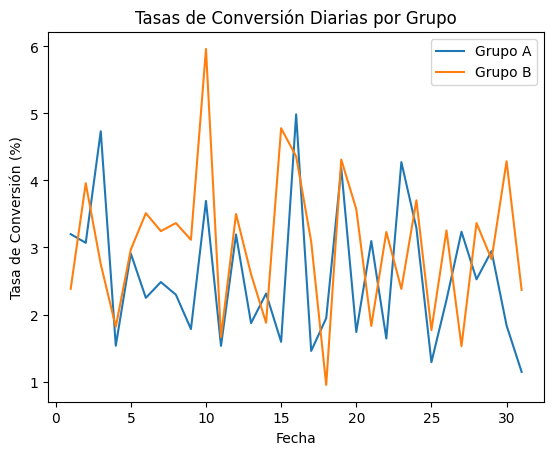

In [30]:
plt.plot(conversion_a['day'], conversion_a['conversion_rate'], label='Grupo A')
plt.plot(conversion_b['day'], conversion_b['conversion_rate'], label='Grupo B')
plt.xlabel('Fecha')
plt.ylabel('Tasa de Conversión (%)')
plt.title('Tasas de Conversión Diarias por Grupo')
plt.legend()
'plt.show()'

- Vemos en el grafico que la tasa de conversion del grupo B tiene un ligero mas de aumento que el de

- Se presento una conversion de 6 unidades el dia 10 para el grupo B y el grupo A tuvo un pico alto con 5 unidades el dia 16.

- Por ahora la version nueva que corresponde al grupo B tiene una mejor preferencia por los usuarios.

    

    


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La limpieza inicial para excluir usuarios en ambos grupos está bien ejecutada, lo cual es clave para asegurar la validez estadística. Todas las gráficas requeridas se han construido correctamente, incluyendo ingreso acumulado, tamaño de pedido promedio acumulado y diferencia relativa. También se incluye el cálculo detallado de la tasa de conversión. El análisis es coherente con la evidencia mostrada. Como mejora de estilo menor, recuerda usar `plt.show()` con paréntesis para que los gráficos se rendericen correctamente.
</div>


### 5. Traza un gráfico de dispersión del número de pedidos por usuario. Haz conclusiones y conjeturas.

In [31]:
#agrupamos los datos por 'visitorId' y contamos el número de pedidos por usuario
orders_per_user = orders_new.groupby('visitorId').size()


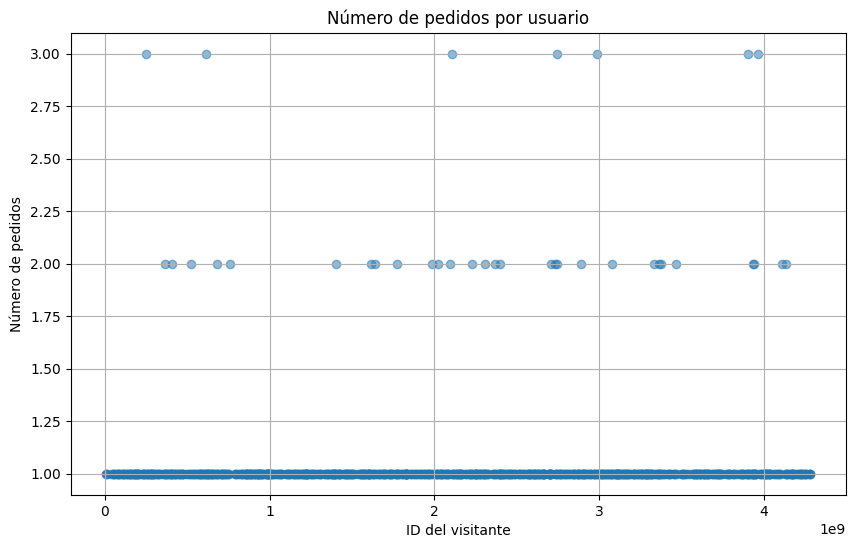

In [32]:
#Hacemos el grafico de dispersion
plt.figure(figsize=(10, 6))
plt.scatter(orders_per_user.index, orders_per_user.values, alpha=0.5)
plt.title('Número de pedidos por usuario')
plt.xlabel('ID del visitante')
plt.ylabel('Número de pedidos')
plt.grid()
plt.show()

- Vemos que la gran mayoria de de pedidos se concetran en 1 pedido por usuario-
- se notan 7 usuarios que tuvieron 3 pedidos y  otras mas 2 pedidos

### 6. Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía

In [33]:
#Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía.
percentile_95 = np.percentile(orders_per_user, 95)
percentile_99 = np.percentile(orders_per_user, 99)  
print(f'Percentil 95: {percentile_95}')
print(f'Percentil 99: {percentile_99}')

Percentil 95: 1.0
Percentil 99: 2.0


In [34]:
# Identifica los usuarios que tienen un número de pedidos por encima del percentil 95 y 99
anomalies_95 = orders_per_user[orders_per_user > percentile_95]
anomalies_99 = orders_per_user[orders_per_user > percentile_99]

print(f'Usuarios con pedidos por encima del percentil 99: {anomalies_99}')


Usuarios con pedidos por encima del percentil 99: visitorId
249864742     3
611059232     3
2108163459    3
2742574263    3
2988190573    3
3908431265    3
3967698036    3
dtype: int64


- Vemos 7 usuarios que tuvieron 3 pedidos

In [35]:

print(f'Usuarios con pedidos por encima del percentil 95: {anomalies_95}')

Usuarios con pedidos por encima del percentil 95: visitorId
249864742     3
366673373     2
406208401     2
522292794     2
611059232     3
678354126     2
759473111     2
1404560065    2
1617417821    2
1637811943    2
1772171838    2
1985475298    2
2025197455    2
2096506107    2
2108163459    3
2232111114    2
2306096143    2
2366521417    2
2397843657    2
2706377257    2
2733145037    2
2742574263    3
2744017357    2
2892265953    2
2988190573    3
3077396270    2
3332057097    2
3362039251    2
3379260072    2
3469608676    2
3908431265    3
3935952912    2
3941503500    2
3967698036    3
4109358064    2
4134830387    2
dtype: int64


- Vemos al conjunto de usuarios que tuvieron 2 y 3 pedidos

### 7. Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.

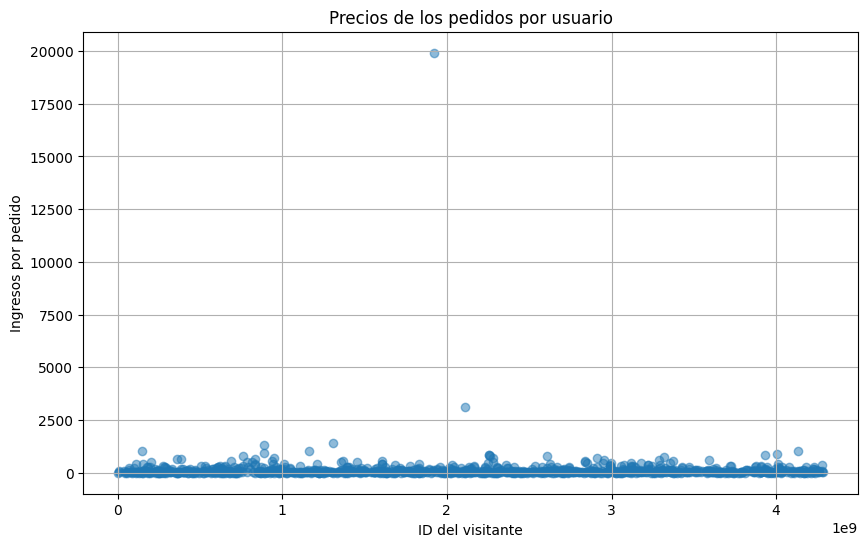

In [36]:

#Trazamos el grafico
plt.figure(figsize=(10, 6))
plt.scatter(orders_new['visitorId'], orders_new['revenue'], alpha=0.5)
plt.title('Precios de los pedidos por usuario')
plt.xlabel('ID del visitante')
plt.ylabel('Ingresos por pedido')
plt.grid()
plt.show()


In [37]:
print(orders_new[['visitorId','revenue']])

       visitorId  revenue
0        5114589     10.8
1        6958315     25.9
2       11685486    100.4
3       39475350     65.4
4       47206413     15.2
...          ...      ...
1011  4259830713     50.1
1012  4278982564    385.7
1013  4279090005    105.3
1014  4281247801     45.6
1015  4283872382     60.6

[1016 rows x 2 columns]


'plt.show()'

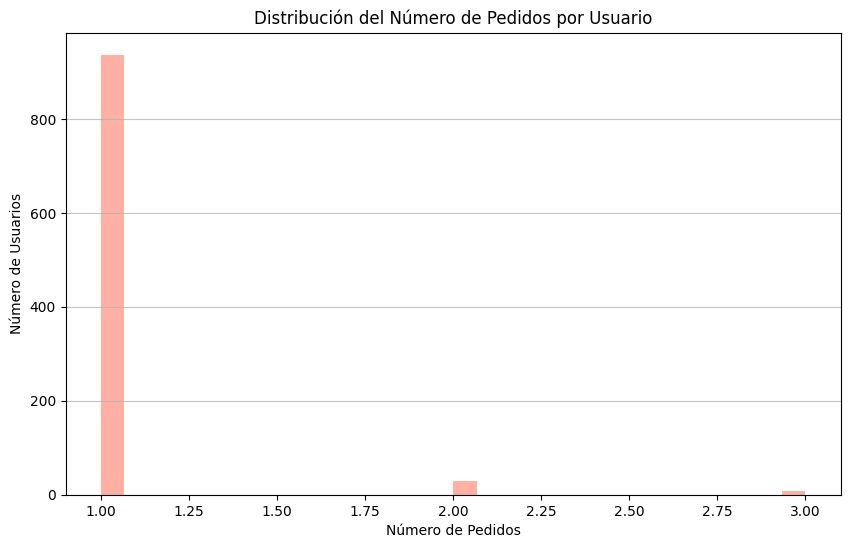

In [38]:
#Grafico de histograma.
plt.figure(figsize=(10, 6))
plt.hist(orders_per_user, bins=30, alpha=0.5, color='tomato')
plt.title('Distribución del Número de Pedidos por Usuario')
plt.xlabel('Número de Pedidos')
plt.ylabel('Número de Usuarios')
plt.grid(axis='y', alpha=0.75)
'plt.show()'

- Tenemos 1 unico pedido muy anormal con un ingreso de mas de 20k y otro un poco arriba del promedio arriba de 2.5k. Este valor tan atipoco de 20k hace algo de ruido a los datos en general.

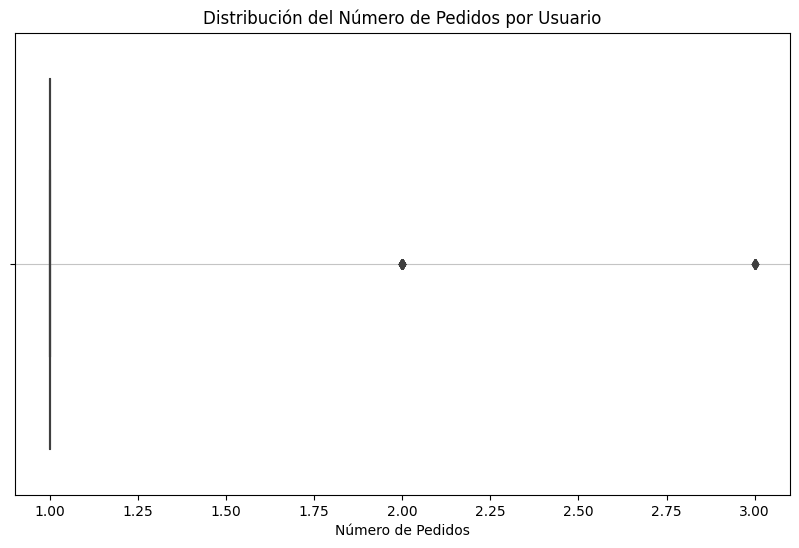

In [39]:
#Hacemos el grafico de bigotes
plt.figure(figsize=(10, 6)) 
sns.boxplot(orders_per_user)
plt.title('Distribución del Número de Pedidos por Usuario')     
plt.xlabel('Número de Pedidos')
plt.grid(axis='y', alpha=0.75)      
plt.show()



<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Atención</b> ⚠️ - Aunque el gráfico de dispersión solicitado cumple con las instrucciones del proyecto, no es la visualización más adecuada para esta variable discreta y altamente concentrada. Este tipo de gráfico dificulta la lectura cuando hay muchos usuarios con la misma cantidad de pedidos.  

Propuesta:

* Usa un **histograma** para observar la distribución de la frecuencia de pedidos por usuario. Esto facilita ver la concentración en "1 pedido" y la cola de valores atípicos.
* Complementa con un **boxplot** para identificar visualmente los valores extremos y apoyar el análisis de percentiles y anomalías.

Ambas visualizaciones dan más claridad sobre patrones y outliers que un gráfico de dispersión en este contexto.

</div>


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

 Gracias Hesus por tus comentarios y observaciones. Y si es el primer nombre que escucho que se escriba con H en vez de Jesus. Ya hice los dos graficos con histograma y boxplot, pero el resultado se ve de esa manera.? Ya que solo existen 3 variables para los pedidos los que tuvieron 1,2 y 3 pedidos, pero si se nota mas remarcado los que tuvieron 1 pedido que es casi la mayoria. 
    
</div>

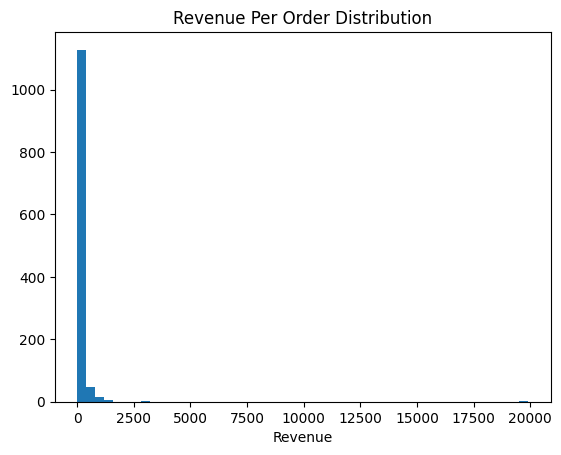

In [40]:
#Histograma complementario
plt.hist(orders['revenue'], bins = 50)
plt.xlabel('Revenue')
plt.title('Revenue Per Order Distribution')
plt.show()

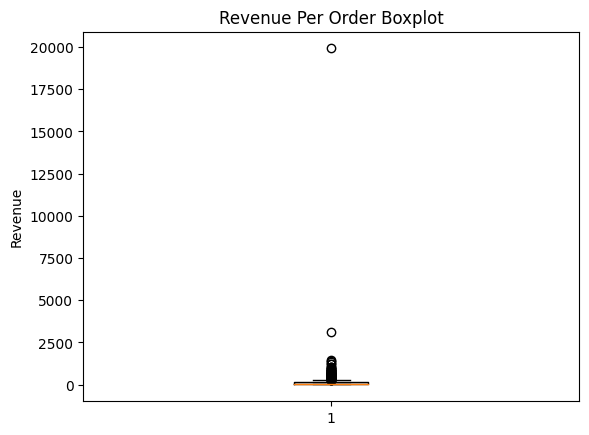

In [41]:
#Boxplot complementario
plt.boxplot(orders['revenue'])
plt.ylabel('Revenue')
plt.title('Revenue Per Order Boxplot')
plt.show()

<div class="alert alert-block alert-warning">
  <b>Comentario del revisor</b> <a class="tocSkip"></a><br>
  Buen trabajo en el proyecto 👏. Te dejo aquí las visualizaciones correctas para comparar un <b>boxplot</b> y un <b>histograma</b> aplicados a tus datos:<br><br>

  ### Interpretación  
  - El <b>boxplot</b> resume de manera compacta la distribución: muestra mediana, cuartiles, rango y outliers. Si se ve muy “aplastado”, significa que la mayoría de los valores están concentrados en un rango pequeño, con pocos valores extremos más altos.  
  - El <b>histograma</b> complementa esta visión al mostrar la frecuencia de los datos en intervalos, lo que permite observar la forma de la distribución (asimetría, concentración y dispersión).  
  - Ambos gráficos resultan más adecuados que el diagrama de dispersión para variables de este tipo, ya que comunican con mayor claridad la distribución y la presencia de valores atípicos.  
</div>


### 8. Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía.


In [42]:
percentile_95_revenue = np.percentile(orders_new['revenue'], 95)
percentile_99_revenue = np.percentile(orders_new['revenue'], 99)
print(f'Percentil 95 de ingresos: {percentile_95_revenue}')
print(f'Percentil 99 de ingresos: {percentile_99_revenue}')


Percentil 95 de ingresos: 414.275
Percentil 99 de ingresos: 830.3


In [43]:
# Aquí se puede definir un punto de corte para considerar un ingreso como una anomalía, por ejemplo, si está por encima del percentil 99
anomalies_revenue = orders_new[orders_new['revenue'] > percentile_99_revenue]
print(f'Usuarios con ingresos por encima del percentil 99: {anomalies_revenue}')

Usuarios con ingresos por encima del percentil 99:       visitorId  group_x  transactionId       date  revenue group_y  day
25    148427295        1      316924019 2019-08-12   1015.9       A   12
209   887908475        1     1347999392 2019-08-21    930.0       A   21
211   888512513        1     3668308183 2019-08-27   1335.6       B   27
276  1164614297        1     1348774318 2019-08-12   1025.8       A   12
309  1307669133        1      666610489 2019-08-13   1425.8       A   13
453  1920142716        1      590470918 2019-08-19  19920.4       B   19
493  2108080724        1     3936777065 2019-08-15   3120.1       B   15
956  4003628586        1     2420050534 2019-08-08    905.8       B    8
980  4133034833        1     3603576309 2019-08-09   1050.0       A    9


### 9. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

In [44]:
#Agrupamos el df orders con los datos en bruto y hacemos el slice del grupo A y B

groupA = orders[orders['group'] == 'A']
groupB = orders[orders['group'] == 'B']

#Damos un slice al id del usuario poniendo los valores unicos y dividimos entre la tabla visitors y s
groupA_conversion = groupA['visitorId'].nunique() / visitors[visitors['group'] == 'A']['visits'].sum()
groupB_conversion = groupB['visitorId'].nunique() / visitors[visitors['group'] == 'B']['visits'].sum()
print(f'Conversión del grupo A: {groupA_conversion}')
print(f'Conversión del grupo B: {groupB_conversion}')



Conversión del grupo A: 0.0268467122117848
Conversión del grupo B: 0.030979065341509834


- Notamos que la diferencia de conversion del grupo A es menor que la del grupo B, hasta ahora sigue ganando el grupo B.

### 10. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

In [45]:


groupA_avg_order_size = groupA['revenue'].mean()
groupB_avg_order_size = groupB['revenue'].mean()
print(f'Tamaño promedio de pedido del grupo A: {groupA_avg_order_size}')
print(f'Tamaño promedio de pedido del grupo B: {groupB_avg_order_size}')



Tamaño promedio de pedido del grupo A: 115.89748653500898
Tamaño promedio de pedido del grupo B: 145.06343750000002


- Vemos una diferencia mayor en el promedio con el grupo B.

In [46]:
#Hacemos una prueba t de student
t_stat, p_value = stats.ttest_ind(groupA['revenue'], groupB['revenue'], equal_var=False)
print(f'Estadístico t: {t_stat}, Valor p: {p_value}')  

Estadístico t: -0.8886193336529402, Valor p: 0.3745072295652421


### 11. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas

In [47]:
#Agrupamos el df orders con los datos filtrados y hacemos el slice del grupo A y B
groupA = orders_new[orders_new['group_y'] == 'A']
groupB = orders_new[orders_new['group_y'] == 'B']
#Damos un slice al id del usuario poniendo los valores unicos y dividimos entre la tabla visitors y s
groupA_conversion = groupA['visitorId'].nunique() / visitors[visitors['group'] == 'A']['visits'].sum()
groupB_conversion = groupB['visitorId'].nunique() / visitors[visitors['group'] == 'B']['visits'].sum()
print(f'Conversión del grupo A con datos filtrados: {groupA_conversion}')
print(f'Conversión del grupo B con datos filtrados: {groupB_conversion}')


Conversión del grupo A con datos filtrados: 0.023751067463706234
Conversión del grupo B con datos filtrados: 0.027912877986889406


- El resultado tuvo un pequeño cambio de 0.004 pero el grupo B sigue teniendo una tasa de conversion mayor. 

### 12. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

In [48]:
#Lo hacemos con los datos filtrados
groupA_f = orders_new[orders_new['group_y'] == 'A']
groupB_f = orders_new[orders_new['group_y'] == 'B']


In [49]:
groupA_avg_order_size = groupA_f['revenue'].mean()
groupB_avg_order_size = groupB_f['revenue'].mean()
print(f'Tamaño promedio de pedido del grupo A: {groupA_avg_order_size}')
print(f'Tamaño promedio de pedido del grupo B: {groupB_avg_order_size}')


Tamaño promedio de pedido del grupo A: 113.7008547008547
Tamaño promedio de pedido del grupo B: 145.34890510948907


In [50]:
#Hacemos una prueba t de student
t_stat, p_value = stats.ttest_ind(groupA_f['revenue'], groupB_f['revenue'], equal_var=False)
print(f'Estadístico t: {t_stat}, Valor p: {p_value}')


Estadístico t: -0.8344812341397613, Valor p: 0.4043438730780977


- Aumento solo un poco el valor del grupo A, el valor del grupo se mantuvo casi igual que sin los datos filtrados con tamaño promedio de 145.

### 13. Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son: 1. Parar la prueba, considerar a uno de los grupos como líder. 2. Parar la prueba, concluir que no hay diferencia entre los grupos. 3. Continuar la prueba.

- Con base a las pruebas realizadas se toma la desicion de parar la prueba.
- Tenemos como ganador al grupo B en todas las pruebas realizadas no es considerable continuar con las pruebas ya que el resultado de A nunca alcanzara al grupo B. 


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Has ejecutado correctamente el análisis de significancia tanto para la conversión como para el tamaño promedio de pedido, con y sin filtrado de usuarios. La aplicación del test de Student está bien justificada, y los resultados son interpretados adecuadamente. También es acertada la decisión final de detener el experimento a favor del grupo B, respaldada por la evidencia estadística. Muy buen cierre analítico del proyecto.
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>
Tu proyecto está <b>Aprobado</b>. Felicidades por terminarlo.  
A continuación, destaco los puntos positivos y las áreas de mejora:

### Puntos Positivos:

* Carga, limpieza y transformación de datos bien ejecutadas.
* Priorización con ICE y RICE correctamente aplicada y explicada.
* Todas las gráficas solicitadas fueron generadas y comentadas con observaciones válidas.
* Los análisis de significancia estadística fueron realizados con metodología apropiada y bien interpretados.
* La decisión final está correctamente fundamentada con base en los resultados.

### Áreas para mejorar:

* Aunque seguiste correctamente las instrucciones al usar un gráfico de dispersión para visualizar los pedidos por usuario, <b>me gustaría regresar tu proyecto solo para que, si gustas, pruebes usar un **histograma** o un **boxplot** en esa sección.
* Ambas opciones son gráficamente más adecuadas para datos discretos como el número de pedidos por usuario y te permitirán visualizar mejor la concentración de valores y detectar outliers de forma más efectiva.

Este ajuste no es obligatorio, pero te invito a experimentar con estas opciones para que veas cómo mejoran la comprensión visual del patrón de datos.

</div>


# Comentario de Segunda Iteración


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>  
Tu proyecto muestra una mejora notable con la inclusión del <b>boxplot</b>. ¡Felicidades por dar este paso! 👏  

### Puntos Positivos:
* Incorporar boxplots es un acierto, porque permiten resumir la distribución de los ingresos en un solo gráfico.  
* Aunque el boxplot se vea “aplastado”, justamente nos da información clave: la mayoría de los pedidos tienen ingresos bajos y existen <i>outliers</i> con valores mucho más altos.  
* La comparación entre el boxplot y el histograma es un punto fuerte: ambos muestran mejor la concentración y dispersión que un simple diagrama de dispersión, que en este caso aporta menos claridad.  

### Área de Mejora:
* Te sugiero en futuras versiones destacar más aún las diferencias entre estas visualizaciones (boxplot, histograma, dispersión) para mostrar cómo cada una responde a una pregunta distinta sobre los datos. Esto refuerza la lógica de tu análisis y da más peso a tus conclusiones.  

</div>
